In [3]:
import matplotlib.pyplot as plt
import json
import numpy as np

exp_files = {
    "Initial":"../../evaluation_results/exp_varying_finetune_dataset_size/before_registration/ACDC/aggregate_results.json",
    "size_0":"../../evaluation_results/exp_varying_finetune_dataset_size/unigradicon_zeroshot/ACDC/aggregate_results.json",
    "io_50":"../../evaluation_results/exp_varying_finetune_dataset_size/unigradicon_io_50/ACDC/aggregate_results.json",
    "size_4":"../../evaluation_results/exp_varying_finetune_dataset_size/unigradicon_size_4/ACDC/aggregate_results.json",
    "size_16":"../../evaluation_results/exp_varying_finetune_dataset_size/unigradicon_size_16/ACDC/aggregate_results.json",
    "size_32":"../../evaluation_results/exp_varying_finetune_dataset_size/unigradicon_size_32/ACDC/aggregate_results.json",
    "size_64":"../../evaluation_results/exp_varying_finetune_dataset_size/unigradicon_size_64/ACDC/aggregate_results.json",
    "size_128":"../../evaluation_results/exp_varying_finetune_dataset_size/unigradicon_size_128/ACDC/aggregate_results.json",
    "size_275":"../../evaluation_results/exp_varying_finetune_dataset_size/unigradicon_size_275/ACDC/aggregate_results.json",
    "before_registration":"../../evaluation_results/exp_varying_finetune_dataset_size/before_registration/ACDC/aggregate_results.json",
}

In [4]:
exp_results = {}
for k,v in exp_files.items():
    with open(v, 'r') as file:
        exp_results[k] = json.load(file)



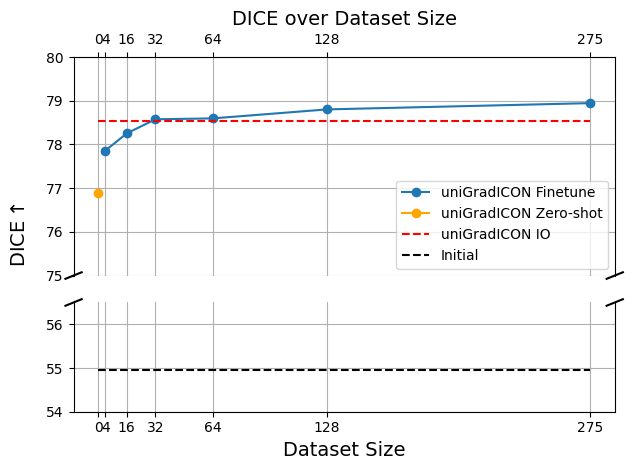

In [6]:
fontsize=14
metric = "dice"
means = []
dataset_sizes = [4, 16, 32, 64, 128, 275]
for j in dataset_sizes:
    means.append(exp_results[f'size_{j}'][metric]['mean'])

# If we were to simply plot pts, we'd lose most of the interesting
# details due to the outliers. So let's 'break' or 'cut-out' the y-axis
# into two portions - use the top (ax) for the outliers, and the bottom
# (ax2) for the details of the majority of our data
f, (ax, ax2) = plt.subplots(2, 1, sharex=True, height_ratios=[2, 1])

# plot the same data on both axes
ax.plot(dataset_sizes, means, marker='o', color="tab:blue", label="uniGradICON Finetune")
ax2.plot(dataset_sizes, means, marker='o', color="tab:blue", label="uniGradICON Finetune")

ax.plot(0, exp_results["size_0"][metric]["mean"], marker='o', color='orange', label='uniGradICON Zero-shot')
ax.hlines(exp_results["io_50"][metric]["mean"], 0, 275, colors='red', linestyles='dashed', label='uniGradICON IO')
ax.hlines(exp_results["Initial"][metric]["mean"], 0, 275, colors='black', linestyles='dashed', label='Initial')

ax2.plot(0, exp_results["size_0"][metric]["mean"], marker='o', color='orange', label='uniGradICON Zero-shot')
ax2.hlines(exp_results["io_50"][metric]["mean"], 0, 275, colors='red', linestyles='dashed', label='uniGradICON IO')
ax2.hlines(exp_results["Initial"][metric]["mean"], 0, 275, colors='black', linestyles='dashed', label='Initial')

# zoom-in / limit the view to different portions of the data
ax.set_ylim(75, 80)  # outliers only
ax2.set_ylim(54, 56.5)  # most of the data

ax2.set_xticks([0,] + dataset_sizes)

# hide the spines between ax and ax2
ax.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax.xaxis.tick_top()
ax.tick_params(labeltop='off')  # don't put tick labels at the top
ax2.xaxis.tick_bottom()



# This looks pretty good, and was fairly painless, but you can get that
# cut-out diagonal lines look with just a bit more work. The important
# thing to know here is that in axes coordinates, which are always
# between 0-1, spine endpoints are at these locations (0,0), (0,1),
# (1,0), and (1,1).  Thus, we just need to put the diagonals in the
# appropriate corners of each of our axes, and so long as we use the
# right transform and disable clipping.

d = .015  # how big to make the diagonal lines in axes coordinates
ratio = 2.
# arguments to pass to plot, just so we don't keep repeating them
kwargs = dict(transform=ax.transAxes, color='k', clip_on=False)
ax.plot((-d, +d), (-d, +d), **kwargs)        # top-left diagonal
ax.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1 - d*ratio, 1 + d*ratio), **kwargs)  # bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d*ratio, 1 + d*ratio), **kwargs)  # bottom-right diagonal

ax.set_title(f'{metric.upper()} over Dataset Size', fontsize=fontsize)
# ax.set_ylabel(metric.upper())
f.supylabel(r"DICE$\uparrow$", fontsize=fontsize)
ax2.set_xlabel('Dataset Size', fontsize=fontsize)

ax.grid(True)
ax2.grid(True)
plt.subplots_adjust(hspace=0.15)
ax.legend()
plt.tight_layout()
plt.savefig('unigradicon_acdcmm_finetune_comparison.png')
plt.show()